In [1]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --- CONFIGURACIÓN DE RUTAS ---
# Ajusta estas rutas a donde tengas descomprimidos tus archivos
WIDER_TRAIN_IMG = './data/Wider/WIDER_train/WIDER_train/images'
WIDER_ANNOTATIONS = './data/Wider/wider_face_split/wider_face_train_bbx_gt.txt'

# Ruta raíz donde están las carpetas PASS.0 y PASS.1
PASS_ROOT = './data/PASS_dataset' 

# Archivo intermedio que generaremos
OUTPUT_CSV = './master_dataset.csv'

# Hiperparámetros
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 1e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Sistema configurado. Usando dispositivo: {DEVICE}")

Sistema configurado. Usando dispositivo: cuda


In [2]:
def create_dataset_csv():
    data_list = []
    
    # ---------------------------------------------------------
    # 1. PROCESAR WIDER FACE (Buscando cara predominante)
    # ---------------------------------------------------------
    print("--- Procesando WIDER FACE ---")
    if not os.path.exists(WIDER_ANNOTATIONS):
        print(f"ERROR: No se encuentra {WIDER_ANNOTATIONS}")
        return None

    with open(WIDER_ANNOTATIONS, 'r') as f:
        lines = f.readlines()

    i = 0
    pbar = tqdm(total=len(lines), desc="Leyendo WIDER")
    
    while i < len(lines):
        filename = lines[i].strip()
        i += 1
        
        try:
            num_faces = int(lines[i].strip())
            i += 1
        except ValueError:
            i += 1
            continue

        full_path = os.path.join(WIDER_TRAIN_IMG, filename)

        if num_faces == 0:
            pbar.update(2) # filename + num_faces line
            continue

        # Load image to get its dimensions for normalization
        img = cv2.imread(full_path)
        if img is None:
            i += num_faces # Skip all face annotations for this missing image
            pbar.update(1 + num_faces)
            continue
        
        img_h, img_w, _ = img.shape

        # BUSCAR CARA PREDOMINANTE (Usando la nueva fórmula)
        max_score = -1
        best_bbox = [0, 0, 0, 0]
        
        for _ in range(num_faces):
            line_content = lines[i].strip().split()
            x, y, w, h = map(int, line_content[:4])
            
            if w < 10 or h < 10:
                i += 1
                continue
            
            area = w * h
            
            # Calculate normalized area
            normalized_area = area / (img_w * img_h) if (img_w * img_h) > 0 else 0

            # Calculate normalized distance to center
            face_center_x = x + w / 2
            face_center_y = y + h / 2
            img_center_x = img_w / 2
            img_center_y = img_h / 2

            dist_x = face_center_x - img_center_x
            dist_y = face_center_y - img_center_y
            distance_to_center = (dist_x**2 + dist_y**2)**0.5
            
            max_distance = ((img_w/2)**2 + (img_h/2)**2)**0.5
            normalized_distance_to_center = (distance_to_center / max_distance) if max_distance > 0 else 0
            
            # Ensure normalizedDistance is clamped between 0 and 1
            clamped_normalized_distance = max(0, min(1, normalized_distance_to_center))

            # New predominance formula: area * (1 - clamped_normalized_distance)**0.6
            score = normalized_area * (1 - clamped_normalized_distance)**0.6

            if score > max_score:
                max_score = score
                best_bbox = [x, y, w, h]
            i += 1

        if os.path.exists(full_path) and max_score > -1:
            data_list.append({
                'path': full_path,
                'has_face': 1.0, 
                'x': best_bbox[0], 'y': best_bbox[1], 'w': best_bbox[2], 'h': best_bbox[3]
            })
        pbar.update(2 + num_faces)
    pbar.close()

    # ---------------------------------------------------------
    # 2. PROCESAR PASS (Estructura PASS.0/PASS_dataset)
    # ---------------------------------------------------------
    print("--- Procesando PASS (Sin Cara) ---")
    pass_subfolders = ['PASS.0']
    
    for subfolder in pass_subfolders:
        # Construimos ruta: ./data/PASS_dataset/PASS.0/PASS_dataset/
        search_path = os.path.join(PASS_ROOT, subfolder, 'PASS_dataset')
        print(f"Buscando en: {search_path}")
        
        images = glob.glob(os.path.join(search_path, '**', '*.jpg'), recursive=True)
        images += glob.glob(os.path.join(search_path, '**', '*.png'), recursive=True)
        
        print(f" -> Encontradas {len(images)} imágenes.")
        
        # Limit to 12880 images from PASS.0 as requested
        images = images[:12880]
        print(f" -> Usando {len(images)} imágenes de PASS.0 para el dataset final.")
        
        for img_path in images:
            data_list.append({
                'path': img_path,
                'has_face': 0.0, 
                'x': 0, 'y': 0, 'w': 0, 'h': 0
            })

    # ---------------------------------------------------------
    # 3. GUARDAR
    # ---------------------------------------------------------
    df = pd.DataFrame(data_list)
    # Mezclar datos
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    df.to_csv(OUTPUT_CSV, index=False)
    
    print(f" Dataset generado con {len(df)} imágenes.")
    print(df['has_face'].value_counts())
    return df


In [3]:
# 1. Generar o Cargar CSV
if os.path.exists(OUTPUT_CSV):
    print("Cargando CSV existente...")
    df_full = pd.read_csv(OUTPUT_CSV)
else:
    df_full = create_dataset_csv()

# --- NUEVO: Limpiar el CSV de imágenes no existentes ---
print(f"Dataset original: {len(df_full)} imágenes")
df_full = df_full[df_full['path'].apply(os.path.exists)]
print(f"Dataset limpio: {len(df_full)} imágenes")
# --- FIN DE LA MODIFICACIÓN ---

# 2. Split Train / Validation
train_df, val_df = train_test_split(df_full, test_size=0.2, random_state=42)

print(f"Datos de Entrenamiento: {len(train_df)}")
print(f"Datos de Validación:    {len(val_df)}")

Cargando CSV existente...
Dataset original: 13585 imágenes
Dataset limpio: 13585 imágenes
Datos de Entrenamiento: 10868
Datos de Validación:    2717


In [4]:
# --- DATASET ---
class FaceDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = row['path']
        
        # Carga con OpenCV
        image = cv2.imread(img_path)
        if image is None: # Fallback si la imagen está corrupta
            return self.__getitem__((idx + 1) % len(self))
            
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h_org, w_org, _ = image.shape
        
        # Obtener etiquetas
        has_face = float(row['has_face'])
        x, y, w_box, h_box = float(row['x']), float(row['y']), float(row['w']), float(row['h'])

        # --- NORMALIZACIÓN DE BBOX (0 a 1) ---
        # Esto es vital para que la red aprenda independientemente del tamaño de la foto
        if has_face == 1:
            x /= w_org
            y /= h_org
            w_box /= w_org
            h_box /= h_org
        else:
            x, y, w_box, h_box = 0.0, 0.0, 0.0, 0.0
            
        # Aplicar transformaciones (Resize, Normalize)
        if self.transform:
            image = self.transform(image)
            
        # Retornamos: Imagen, Label Clasificación, Label Bbox
        return image, torch.tensor([has_face], dtype=torch.float32), torch.tensor([x, y, w_box, h_box], dtype=torch.float32)

# --- MODELO ---
class FaceDetector(nn.Module):
    def __init__(self, train_last_n_blocks=1):
        super(FaceDetector, self).__init__()
        # Backbone: MobileNetV2 (ligero y rápido para inferencia)
        backbone = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        
        # Congelar la mayoría de las capas
        for param in backbone.parameters():
            param.requires_grad = False
            
        # Descongelar los últimos N bloques de features
        # MobileNetV2 tiene 19 bloques de 'features' (0-18)
        if train_last_n_blocks > 0:
            for i in range(len(backbone.features) - train_last_n_blocks, len(backbone.features)):
                for param in backbone.features[i].parameters():
                    param.requires_grad = True
        
        self.features = backbone.features
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Head 1: Clasificador (¿Hay cara?)
        self.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(1280, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid() 
        )
        
        # Head 2: Regresor (Bounding Box x,y,w,h)
        self.regressor = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(1280, 64),
            nn.ReLU(),
            nn.Linear(64, 4),
            nn.Sigmoid() # Salida 0-1 (coordenadas normalizadas)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x), self.regressor(x)

In [5]:

def train_epoch(loader, model, optimizer, criterion_cls, criterion_bbox, epoch):
    """
    Función de entrenamiento para una sola época.
    MODIFICADO: Acepta el número de época para mostrarlo en la barra de progreso.
    """
    model.train()
    running_loss = 0.0
    
    # MODIFICADO: 
    # - leave=True: Mantiene la barra de progreso en pantalla después de completarse.
    # - desc: Muestra la época actual y el total de épocas.
    loop = tqdm(loader, leave=True, desc=f"Epoch {epoch+1}/{EPOCHS} Training")
    
    for images, labels_c, labels_b in loop:
        images, labels_c, labels_b = images.to(DEVICE), labels_c.to(DEVICE), labels_b.to(DEVICE)
        
        optimizer.zero_grad()
        pred_c, pred_b = model(images)
        
        loss_c = criterion_cls(pred_c, labels_c)
        mask = labels_c.view(-1, 1).expand_as(pred_b)
        loss_b = criterion_bbox(pred_b * mask, labels_b * mask)
        
        loss = loss_c + (5.0 * loss_b)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        # Muestra la pérdida del batch actual en la barra de progreso
        loop.set_postfix(batch_loss=f"{loss.item():.4f}")
        
    avg_loss = running_loss / len(loader)
    # Al final, actualiza la barra para mostrar la pérdida promedio de la época
    loop.set_postfix(avg_epoch_loss=f"{avg_loss:.4f}")
    return avg_loss

def validate_epoch(loader, model, criterion_cls, criterion_bbox):
    """Función de validación (sin cambios)."""
    model.eval()
    running_loss = 0.0
    
    with torch.no_grad():
        for images, labels_c, labels_b in loader:
            images, labels_c, labels_b = images.to(DEVICE), labels_c.to(DEVICE), labels_b.to(DEVICE)
            
            pred_c, pred_b = model(images)
            
            loss_c = criterion_cls(pred_c, labels_c)
            mask = labels_c.view(-1, 1).expand_as(pred_b)
            loss_b = criterion_bbox(pred_b * mask, labels_b * mask)
            
            loss = loss_c + (5.0 * loss_b)
            running_loss += loss.item()
            
    return running_loss / len(loader)

--- Iniciando Entrenamiento por 10 épocas ---


Epoch 1/10 Training:   0%|          | 0/340 [00:00<?, ?it/s]

Epoch [1/10] Summary -> Avg Train Loss: 0.2061 | Validation Loss: 0.0652
  -> Checkpoint guardado en época 1


Epoch 2/10 Training:   0%|          | 0/340 [00:00<?, ?it/s]

Epoch [2/10] Summary -> Avg Train Loss: 0.0623 | Validation Loss: 0.0473
  -> Checkpoint guardado en época 2


...

Epoch [8/10] Summary -> Avg Train Loss: 0.0250 | Validation Loss: 0.0442


Epoch 9/10 Training:   0%|          | 0/340 [00:00<?, ?it/s]

Epoch [9/10] Summary -> Avg Train Loss: 0.0216 | Validation Loss: 0.0446


Epoch 10/10 Training:   0%|          | 0/340 [00:00<?, ?it/s]

Epoch [10/10] Summary -> Avg Train Loss: 0.0222 | Validation Loss: 0.0493


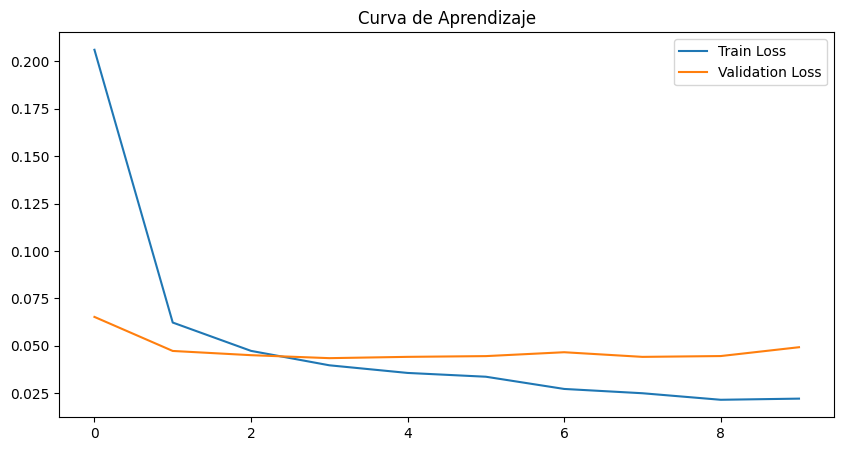

--- Exportando modelo a ONNX ---


OnnxExporterError: Module onnx is not installed!

In [6]:
# 1. Transformaciones
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 2. DataLoaders
train_ds = FaceDataset(train_df, transform=transform)
val_ds = FaceDataset(val_df, transform=transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# 3. Inicializar Modelo
model = FaceDetector(train_last_n_blocks=1).to(DEVICE)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)
criterion_cls = nn.BCELoss()
criterion_bbox = nn.MSELoss()

# 4. Bucle de Entrenamiento
train_losses = []
val_losses = []

print(f"--- Iniciando Entrenamiento por {EPOCHS} épocas ---")

for epoch in range(EPOCHS):
    # MODIFICADO: Pasamos el número de la época a la función de entrenamiento
    train_loss = train_epoch(train_loader, model, optimizer, criterion_cls, criterion_bbox, epoch)
    val_loss = validate_epoch(val_loader, model, criterion_cls, criterion_bbox)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    # Este print sigue siendo útil para ver un resumen claro al final de cada época,
    # especialmente la pérdida de validación.
    print(f"Epoch [{epoch+1}/{EPOCHS}] Summary -> Avg Train Loss: {train_loss:.4f} | Validation Loss: {val_loss:.4f}")
    
    # Guardar el mejor modelo
    if epoch == 0 or val_loss < min(val_losses[:-1]):
        torch.save(model.state_dict(), "face_detector_best.pth")
        print(f"  -> Checkpoint guardado en época {epoch+1}")

# 5. Visualizar Resultados
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.legend()
plt.title("Curva de Aprendizaje")
plt.show()

# 6. Exportar a ONNX
print("--- Exportando modelo a ONNX ---")
model.load_state_dict(torch.load("face_detector_best.pth"))
model.eval()

dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)

torch.onnx.export(
    model,
    dummy_input,
    "face_detector.onnx",
    verbose=False,
    input_names=['input'],
    output_names=['classification', 'bbox'],
    opset_version=12
)

print("¡ÉXITO! Modelo guardado como 'face_detector.onnx'")


In [7]:
torch.onnx.export(
    model,
    dummy_input,
    "face_detector.onnx",
    verbose=False,
    input_names=['input'],
    output_names=['classification', 'bbox'],
    opset_version=12
)

print("¡ÉXITO! Modelo guardado como 'face_detector.onnx'")

¡ÉXITO! Modelo guardado como 'face_detector.onnx'
